In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update('jax_platform_name', 'cpu')

import pickle 
# import os

import numpy as np

import matplotlib.pyplot as plt
import loco_mujoco.evaluation.evaluation_prosthesis as eval_pros

import importlib
importlib.reload(eval_pros)

postprocess_handler = eval_pros.PostProcessMetricsHandler()

# from loco_mujoco.evaluation.evaluation_prosthesis import PostProcessMetricsHandler
# import importlib

# postprocess_handler = PostProcessMetricsHandler()

# importlib.reload(importlib.import_module("evaluation_prosthesis"))

# postprocess_handler = PostProcessMetricsHandler()

min_walk_step_length = 60 #60 # based on testing with initial data
min_contact_length = 20

/home/nadinebadie/anaconda3/envs/loco-mujoco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Only read joint data from file
with open("/home/nadinebadie/loco-mujoco/prosthesis_evaluation/joint_data_walk_SkeletonMuscle.pkl", "rb") as f:
    joint_data_baseline = pickle.load(f)

In [3]:
# With Gastro, Ankle stiffness 1200, Socket_ty Range 0.02 in Joint and Joint Force; Phase 1 full randomization --> Phase 2 focus on different alignments 
# run_names = {

#     'P2': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250827_222323_evaluation_results_1000steps.pkl',
    
#     'P2_Z10°_Rand':'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-30/23-26-49/20250831_105020_eval_1000steps_talus_z_10deg_prosthesis_body_orientation.pkl',
#     # 'P2_Z10°_t':'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-30/14-50-08/20250830_234327_evaluation_results_1000steps_0seed.pkl',
#     'P2_Z10°':'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-30/14-50-08/20250831_105111_eval_1000steps_talus_z_10deg_prosthesis_body_orientation.pkl',
#     'P2_Z10°_GenRand': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250904_164546_eval_1000steps_talus_z_10deg_prosthesis_body_orientation_FallOnlyBeg.pkl',
    
#     # 'P2_Z-10°_Rand': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-01/14-41-07/20250904_092424_eval_1000steps_talus_z_-10deg_prosthesis_body_orientation.pkl',
#     'P2_Z-10°': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-01/10-45-53/20250904_092337_eval_1000steps_talus_z_-10deg_prosthesis_body_orientation.pkl',
#     'P2_Z-10°_GenRand': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250904_104832_eval_1000steps_talus_z_-10deg_prosthesis_body_orientation.pkl',
    
#     'P2_X2C_Rand': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-31/07-15-14/20250831_113525_eval_1000steps_talus_x_2cm_prosthesis_body_position.pkl',
#     'P2_X2C': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-31/03-21-38/20250831_105346_eval_1000steps_talus_x_2cm_prosthesis_body_position.pkl',
#     'P2_X2C_GenRand': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250904_104745_eval_1000steps_talus_x_2cm_prosthesis_body_position.pkl',
    
#     'P2_X-2C_Rand': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-31/15-06-42/20250904_170856_eval_1000steps_talus_x_-2cm_prosthesis_body_position.pkl',
#     'P2_X-2C': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-31/11-11-44/20250904_170828_eval_1000steps_talus_x_-2cm_prosthesis_body_position.pkl',
#     'P2_X-2C_GenRand': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250904_163135_eval_1000steps_talus_x_-2cm_prosthesis_body_position.pkl',
    
#     # "All_Neg": "/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-26/23-28-37/20250901_230702_evaluation_results_1000steps_0seed.pkl",
# }

# run_names = {
#     'P2' : '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250827_222323_evaluation_results_1000steps.pkl',
#     'P2_Z10°': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19//20250916_091835_eval_1000steps_talus_z_10deg_prosthesis_body_orientation.pkl',
#     'P2_Z5°': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250916_092424_eval_1000steps_talus_z_5deg_prosthesis_body_orientation.pkl',
#     'P2_Z-10°':'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250916_091011_eval_1000steps_talus_z_-10deg_prosthesis_body_orientation_Fall.pkl',
#     'P2_Z-5°': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250916_091608_eval_1000steps_talus_z_-5deg_prosthesis_body_orientation.pkl',
#     'P2_X20mm':'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250916_091727_eval_1000steps_talus_x_2cm_prosthesis_body_position.pkl',
#     'P2_X-20mm': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250916_090905_eval_1000steps_talus_x_-2cm_prosthesis_body_position.pkl',
# }


run_names = {
   'P2': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162834_pylon_socket_ori_x/eval_1000steps_pylon_socket_x_0deg_prosthesis_body_orientation.pkl',
    'P2_Rand_Z-15mm': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_163036_pylon_socket_pos_z/eval_1000steps_pylon_socket_z_-15mm_prosthesis_body_position.pkl',
    'P2_Rand_Z15mm':'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_163036_pylon_socket_pos_z/eval_1000steps_pylon_socket_z_15mm_prosthesis_body_position.pkl',
    'P2_Rand_X6°':'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162834_pylon_socket_ori_x/eval_1000steps_pylon_socket_x_6deg_prosthesis_body_orientation.pkl',
    'P2_Rand_X-6°': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162834_pylon_socket_ori_x/eval_1000steps_pylon_socket_x_-6deg_prosthesis_body_orientation.pkl',
    'P2_Z-15mm': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-02/17-20-02/20251003_145615_evaluation_results_1000steps_0seed.pkl',
    'P2_Z15mm': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-02/21-15-37/20251003_145654_evaluation_results_1000steps_0seed.pkl',
    'P2_X-10°': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-03/01-11-56/20251003_145852_evaluation_results_1000steps_0seed.pkl',
    'P2_X10°': '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-03/05-05-53/20251003_153959_evaluation_results_1000steps_0seed.pkl'
}

# Dictionary to hold loaded data
all_loaded_data = {}

for var_name, path in run_names.items():
    with open(path, "rb") as f:
        loaded_data =  pickle.load(f) #, encoding='latin1')
        print(f"Loaded data for {var_name} from {path}: {loaded_data.keys()}")
        all_loaded_data[var_name] = loaded_data

Loaded data for P2 from /home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162834_pylon_socket_ori_x/eval_1000steps_pylon_socket_x_0deg_prosthesis_body_orientation.pkl: dict_keys(['total_steps', 'n_envs', 'all_grf_l', 'all_grf_r', 'all_foot_ground_contact_left', 'all_foot_ground_contact_right', 'all_sensor_force', 'sensor_force_names', 'sum_step_activations', 'step_norm_activations', 'sum_muscles_activations', 'step_muscles_norm_activations', 'step_num_norm_activations', 'evaluation_muscle_groups', 'evaluation_joint_names', 'evaluation_muscle_names', 'all_actions', 'all_actuator_names', 'all_body_poses', 'evaluation_body_names', 'root_angle', 'root_velocity', 'root_forces_constraint', 'root_forces_smooth', 'root_forces_applied', 'root_torques', 'root_energy_exp', 'root_angle_per_step_left', 'root_angle_per_step_right', 'root_velocity_per_step_left', 'root_velocity_per_step_right', 'root_forces_constraint_per_step_left', 'root_forces_constraint_per_s

KeyboardInterrupt: 

In [8]:
# FINAL CODE 
import loco_mujoco.evaluation.evaluation_prosthesis as eval_pros

import importlib
importlib.reload(eval_pros)

postprocess_handler = eval_pros.PostProcessMetricsHandler()

# Get steps from GRF instead of Contact 
min_walk_step_length_left = 30
min_walk_step_length = 40 #70 #60
run_step_data={}

for run_key, run_dict in all_loaded_data.items():
    all_grf_l = np.array(run_dict.get("all_grf_l"))
    all_grf_r = np.array(run_dict.get("all_grf_r"))
    z_grf_l = all_grf_l[:,5]
    z_grf_r = all_grf_r[:,5]

    step_start_left = postprocess_handler.get_start_steps_from_grfZ(z_grf_l, min_walk_step_length=min_walk_step_length_left)
    step_start_right = postprocess_handler.get_start_steps_from_grfZ(z_grf_r, min_walk_step_length=min_walk_step_length)
    contact_length_left = postprocess_handler.get_contact_lengths_from_grfZ(z_grf_l, min_walk_step_length=min_walk_step_length_left, threshold = 0.5)
    contact_length_right = postprocess_handler.get_contact_lengths_from_grfZ(z_grf_r, min_walk_step_length=min_walk_step_length, threshold = 0.5)
    all_contact_left = postprocess_handler.get_contact_from_grfZ(z_grf_l)
    all_contact_right = postprocess_handler.get_contact_from_grfZ(z_grf_r)
    # single_support_right_time, single_support_left_time = postprocess_handler.compute_single_support_time(all_contact_right, all_contact_left)
    single_support_right_time_per_step, single_support_left_time_per_step = postprocess_handler.compute_single_support_per_step(all_contact_right,all_contact_left, step_start_right, step_start_left)
    # # print('step_start_left', step_start_left)
    # print('step_start_right', step_start_right)
    # # print('contact_length_left', contact_length_left)
    # print('z_grf_r', z_grf_r)
    # print('contact_length_right', contact_length_right)
    
    run_step_data[run_key] = {
        "step_start_left": step_start_left,
        "step_start_right": step_start_right,
        "contact_length_left": contact_length_left, 
        "contact_length_right": contact_length_right, 
        "all_contact_left": all_contact_left, 
        "all_contact_right": all_contact_right, 
        # "single_support_right_time": single_support_right_time, 
        # "single_support_left_time": single_support_left_time,
        "single_support_right_per_step": single_support_right_time_per_step, 
        "single_support_left_per_step": single_support_left_time_per_step

    }

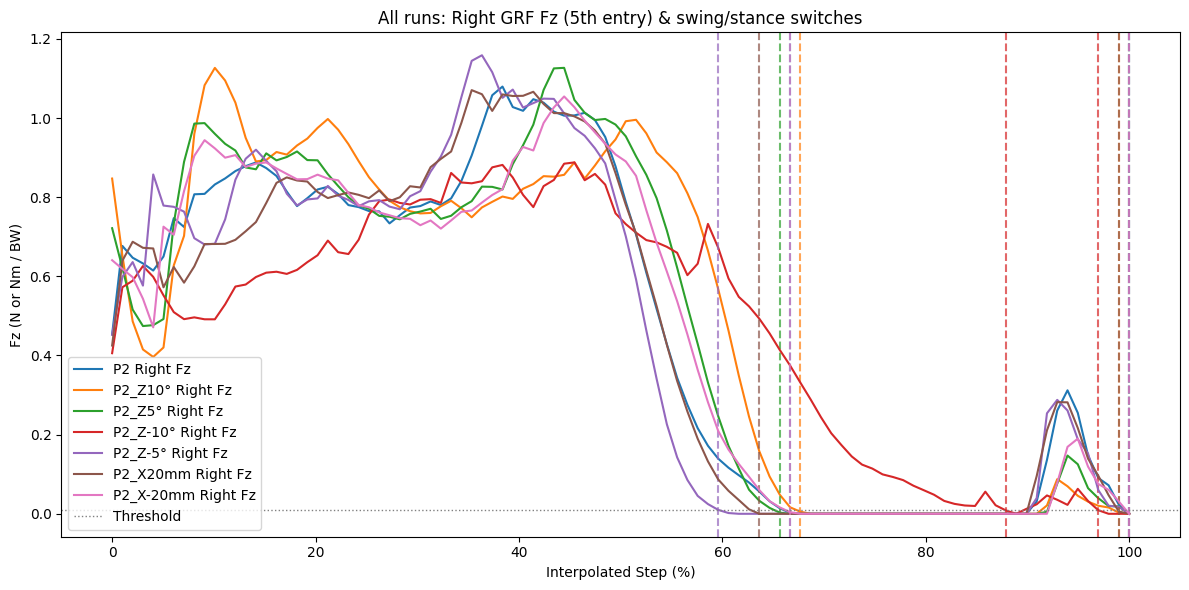

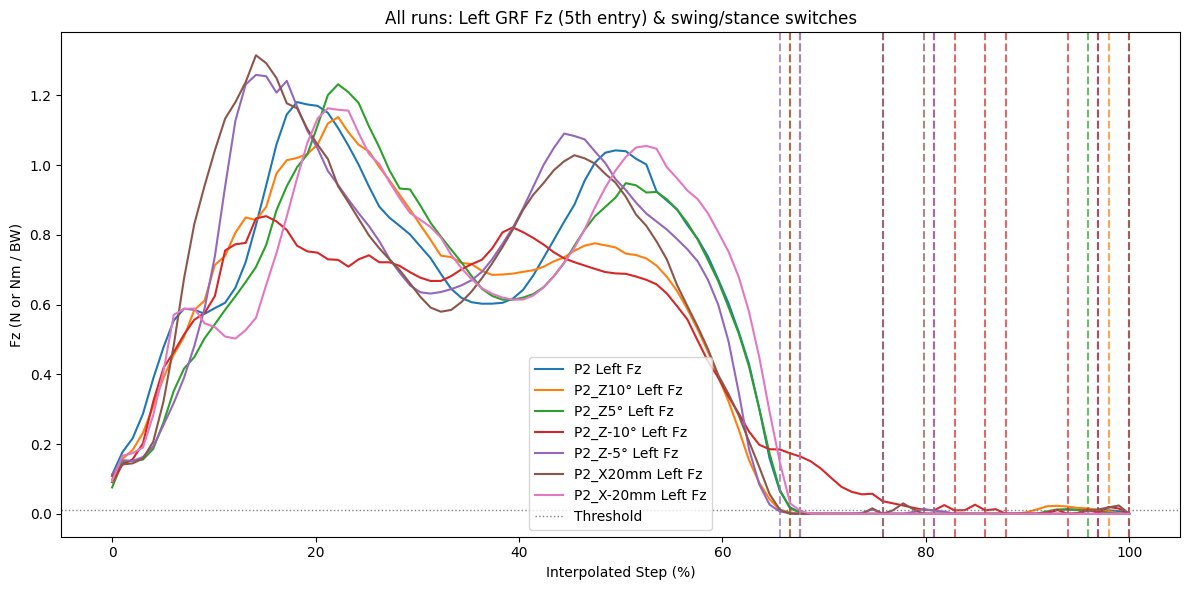

left_switches:  {'P2': [67, 96], 'P2_Z10°': [66, 97], 'P2_Z5°': [67, 95], 'P2_Z-10°': [80, 82, 85, 87, 93, 96, 99], 'P2_Z-5°': [65, 75, 80], 'P2_X20mm': [66, 75, 79, 99], 'P2_X-20mm': [67]}
right_swithces:  {'P2': [66, 99], 'P2_Z10°': [67, 98], 'P2_Z5°': [65, 99], 'P2_Z-10°': [87, 96], 'P2_Z-5°': [59, 99], 'P2_X20mm': [63, 98], 'P2_X-20mm': [66, 99]}


In [9]:
# Detect and save mean and std of stance to swing phase, determined by the Fz in GRF for left and right foot
# Where mean turns 0 for first time 
importlib.reload(eval_pros)

postprocess_handler = eval_pros.PostProcessMetricsHandler()

left_switches, right_switches = postprocess_handler.plot_grf_Fz_switch_all_runs(
        #grf_components,
        all_loaded_data,
        run_step_data,
        interp_len=100,
        body_weight_to_normalize = 86.6*9.81,
    )

print('left_switches: ', left_switches)
print('right_swithces: ', right_switches)

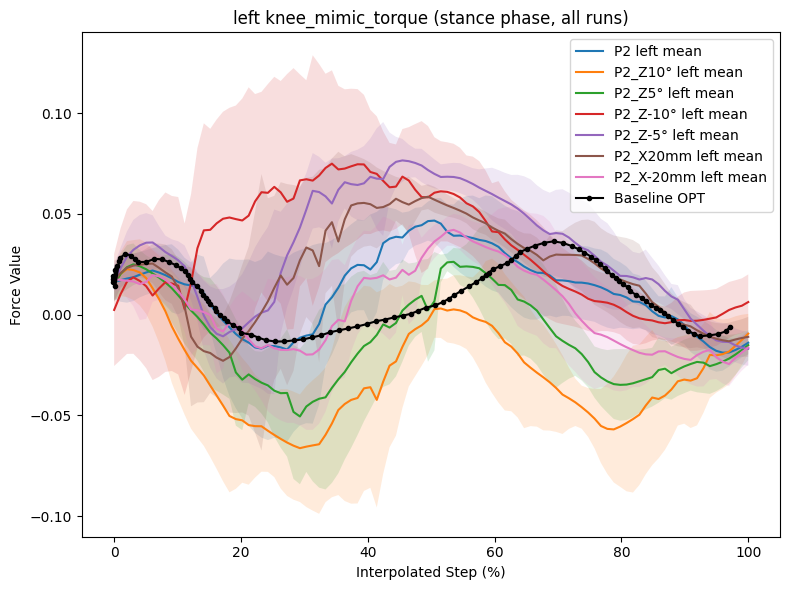

In [ ]:
import re
# Plot Knee torque z with baseline data from Schmalz 

alignment_baseline_data = "/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Alignment_Data_Schmalz_2002.csv"


importlib.reload(eval_pros)
postprocess_handler = eval_pros.PostProcessMetricsHandler()
direction = "z"

postprocess_handler.plot_sensor_force_symmetry_all_runs_stance_compare_baseline_side(
    all_loaded_data,
    run_step_data,
    direction,
    right_switches,
    left_switches,
    prosthesis_side='left',
    interp_len=100,
    body_weight_to_normalize=86.6*9.81,
    baseline_data=alignment_baseline_data
)

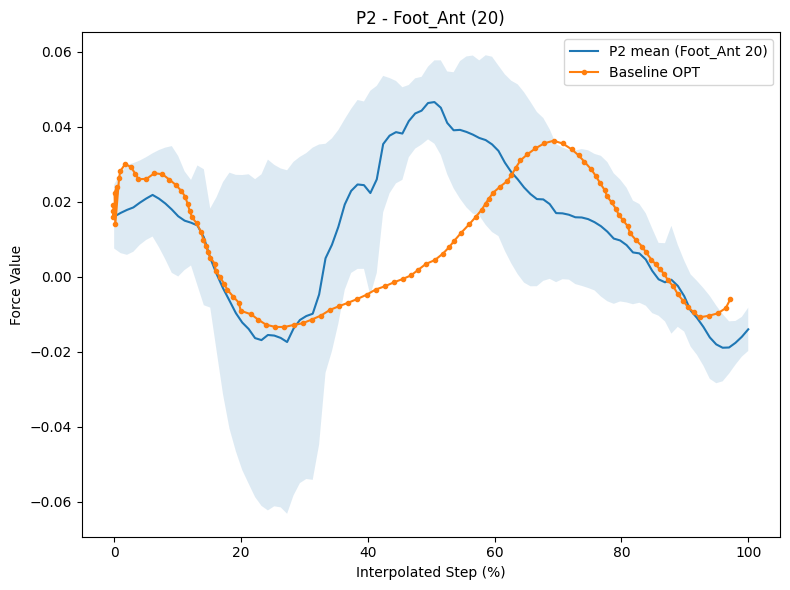

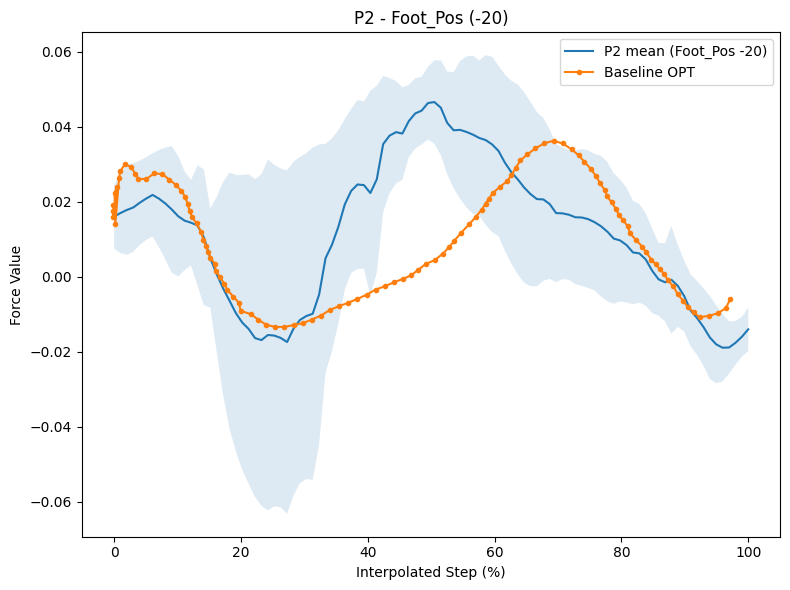

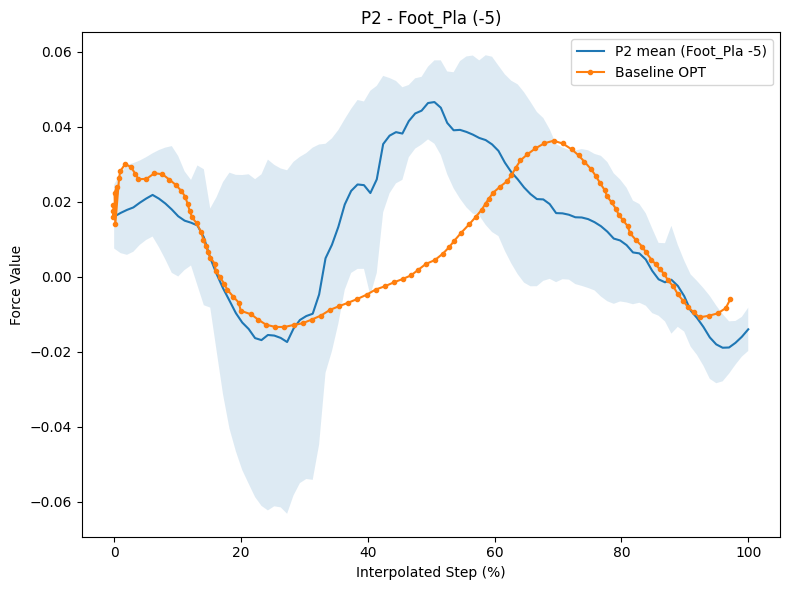

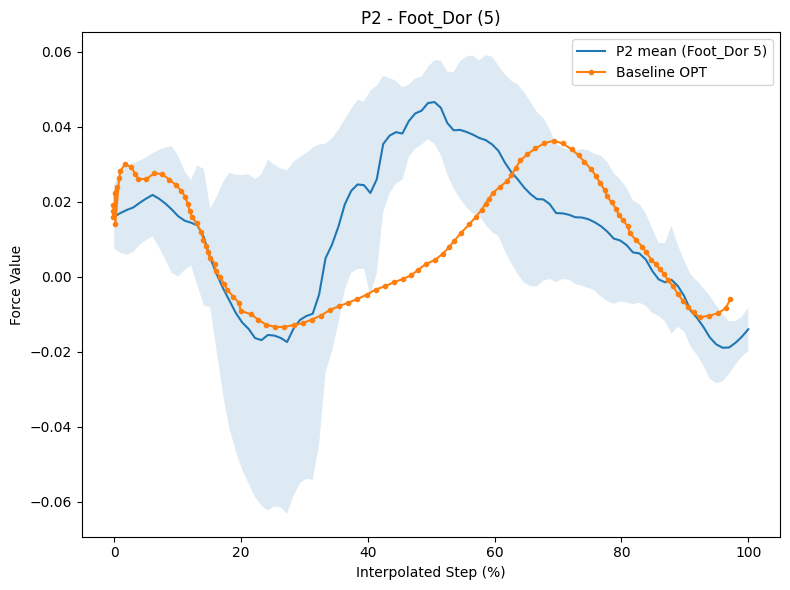

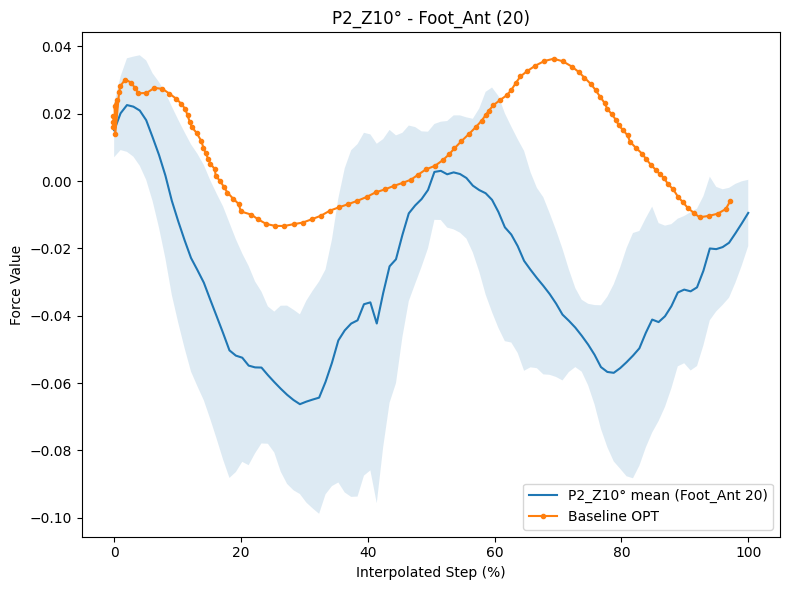

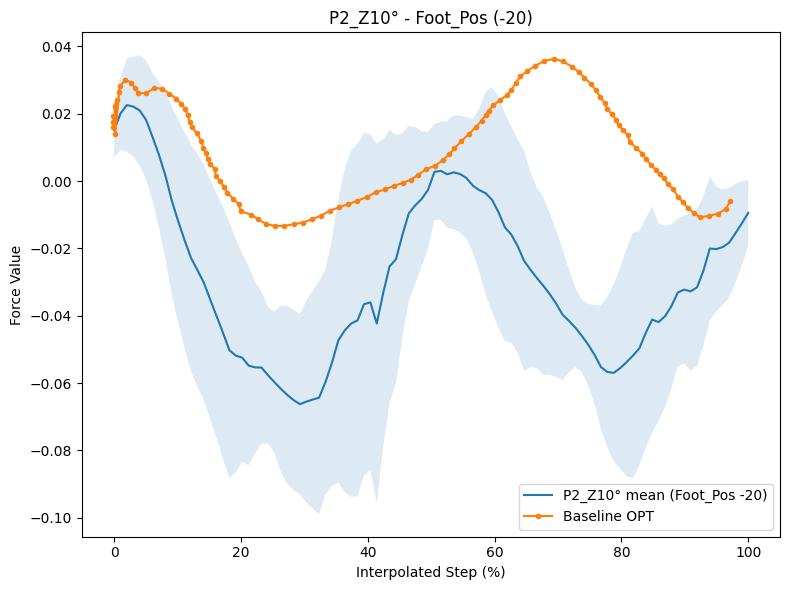

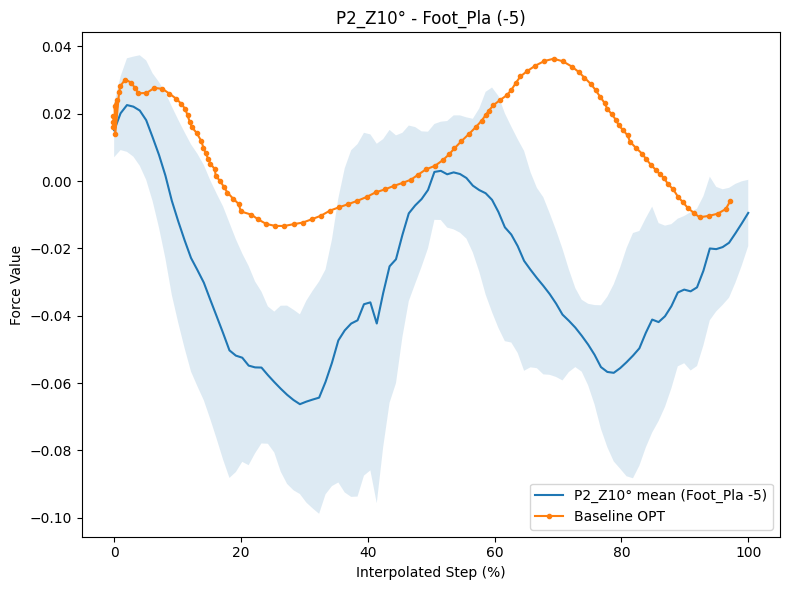

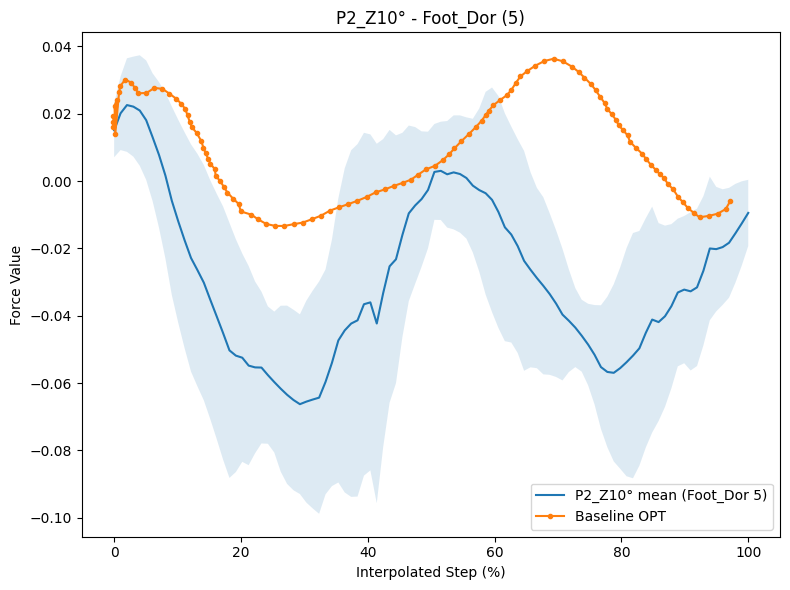

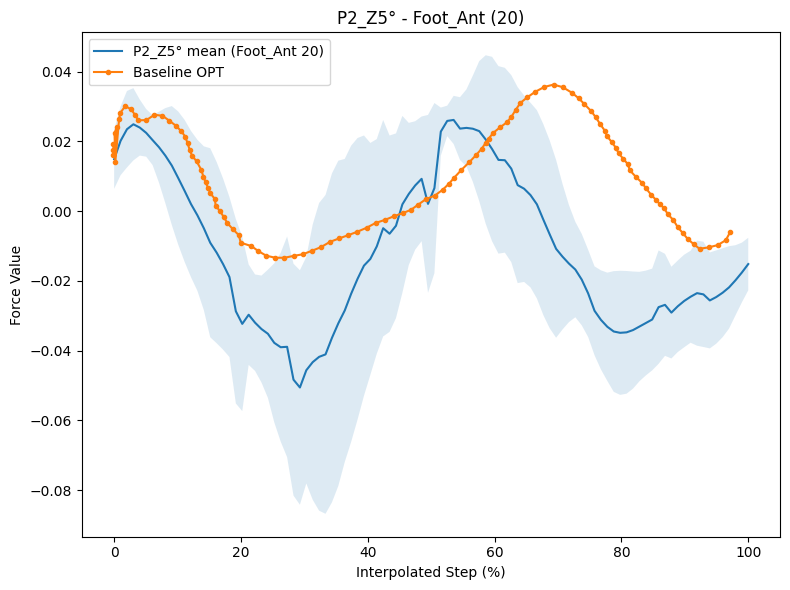

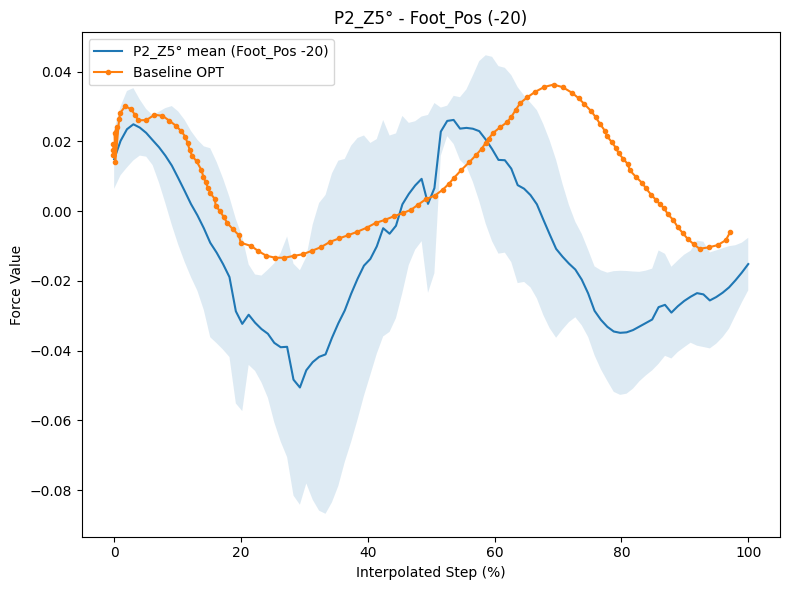

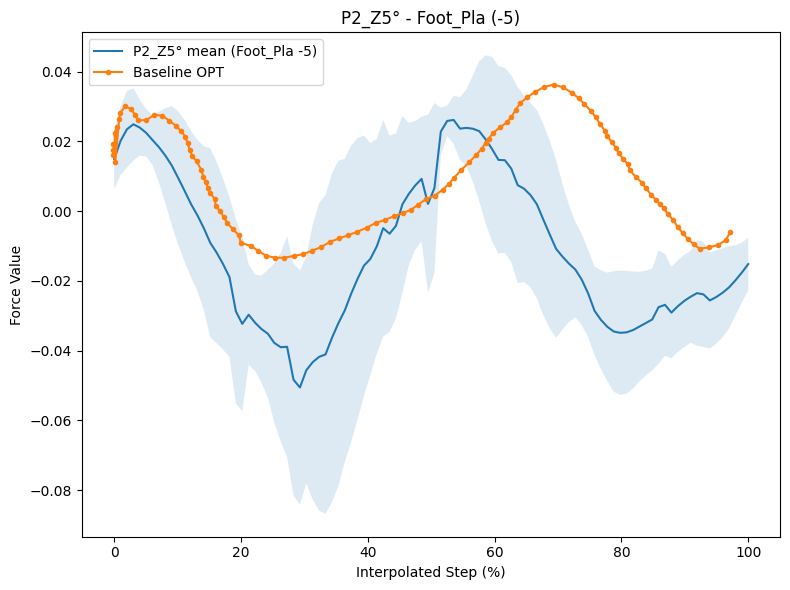

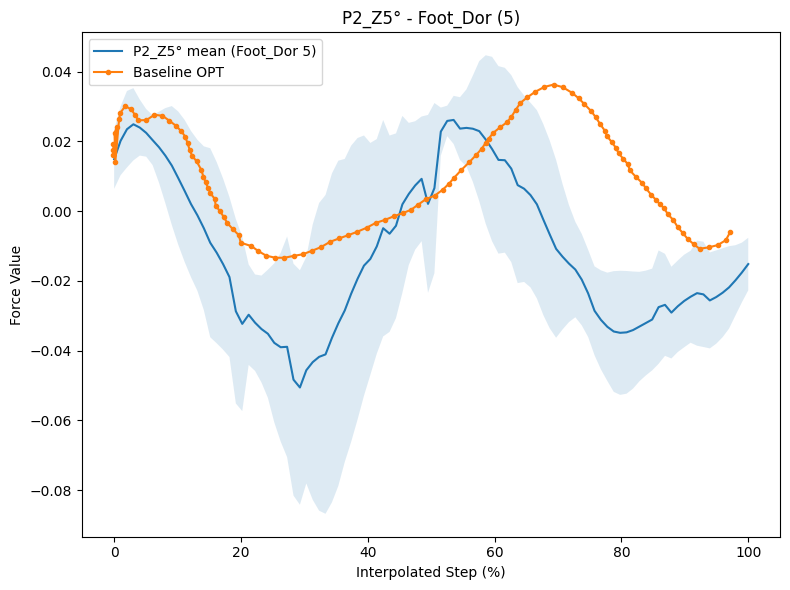

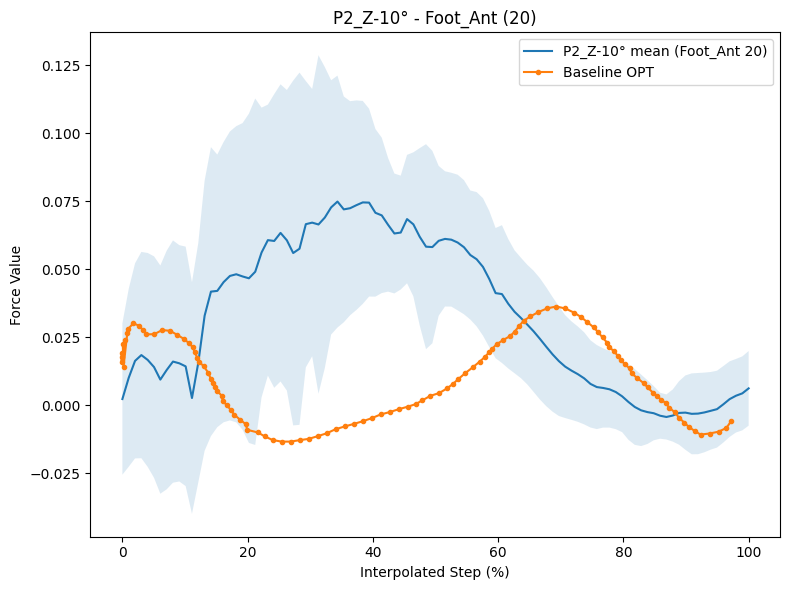

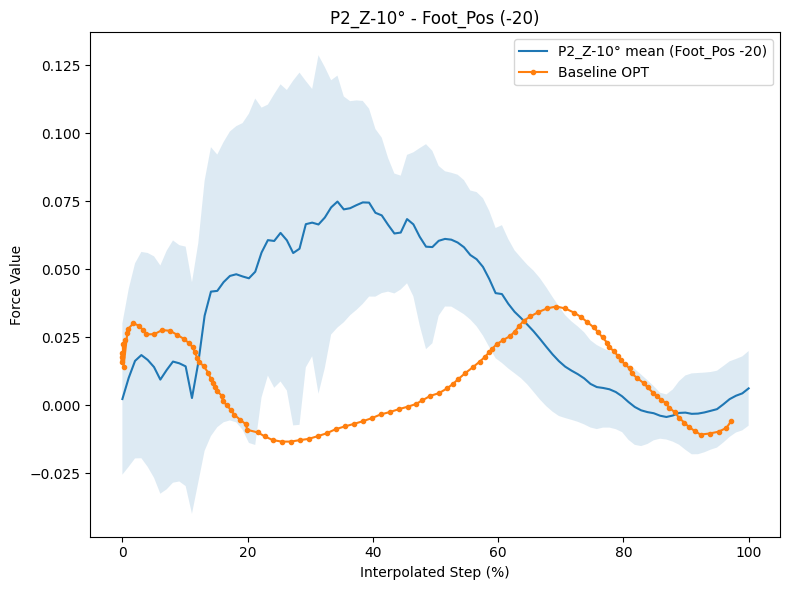

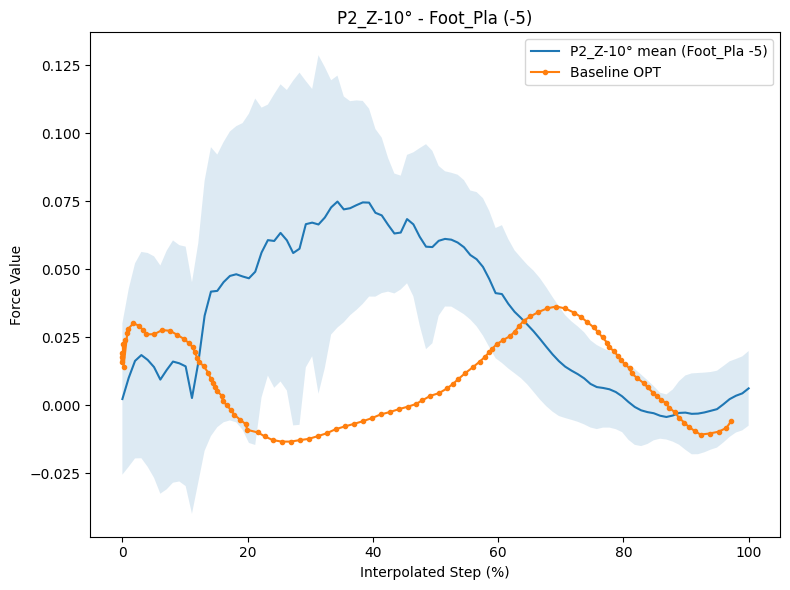

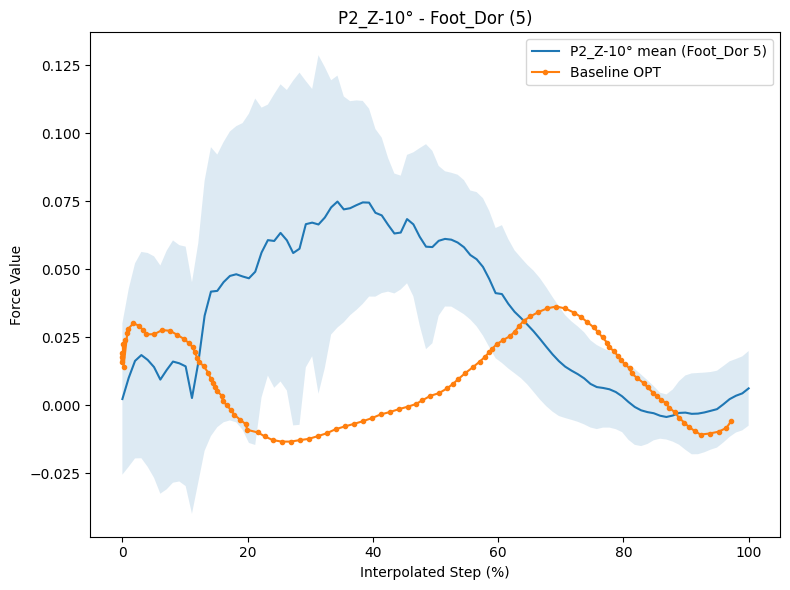

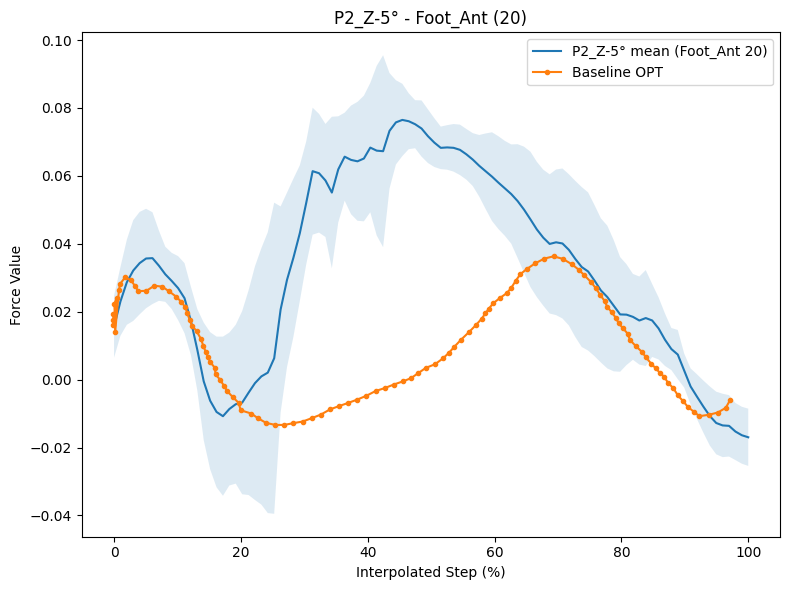

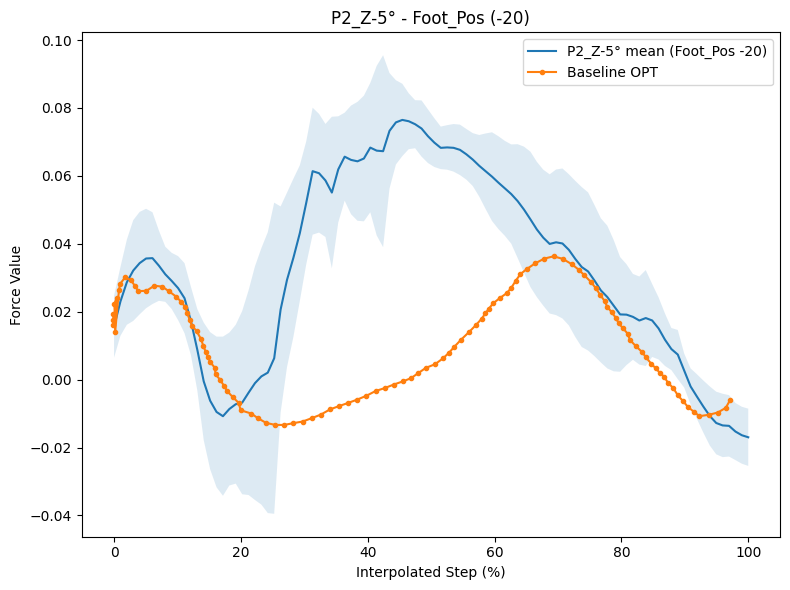

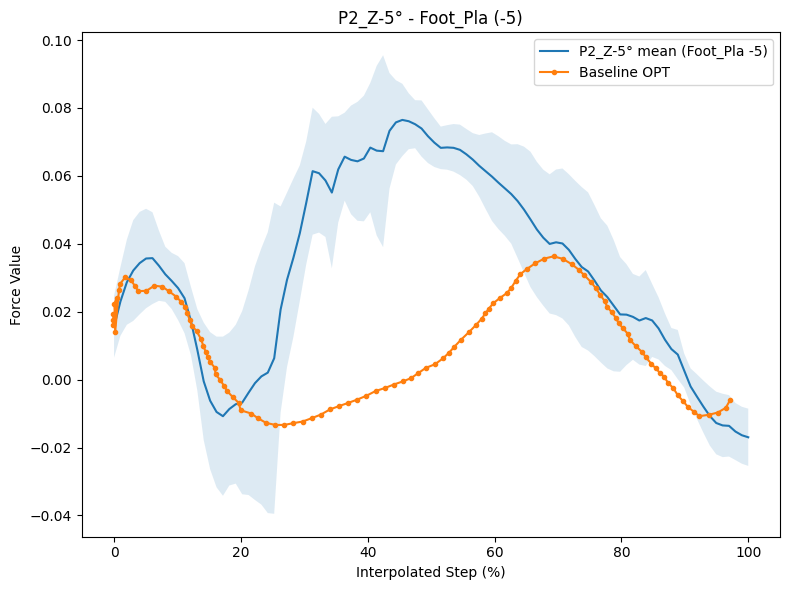

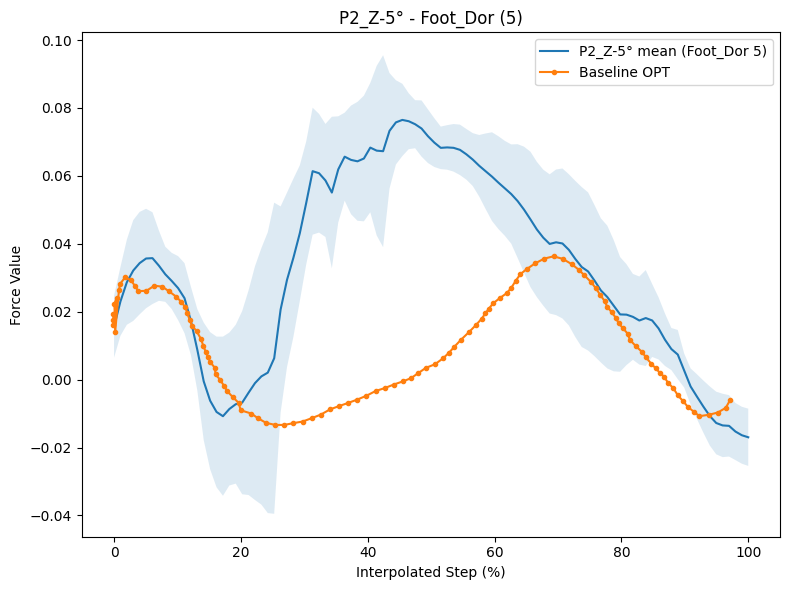

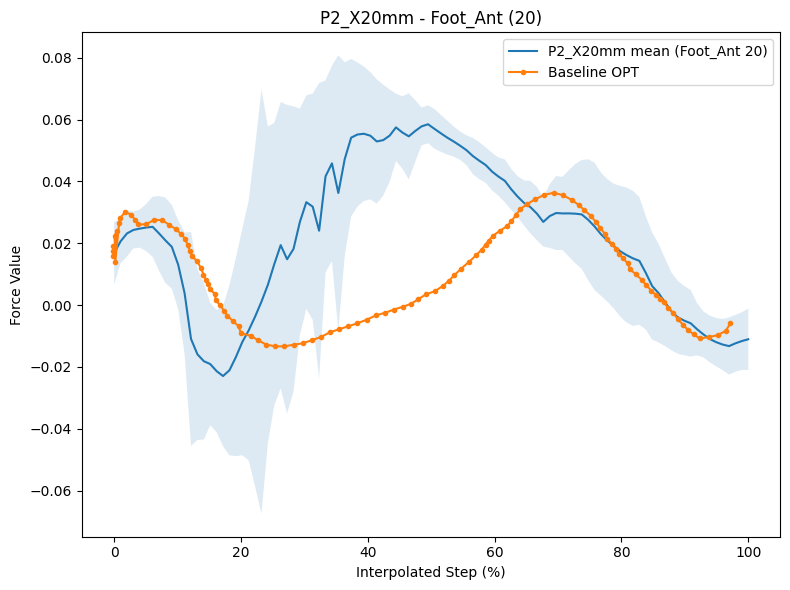

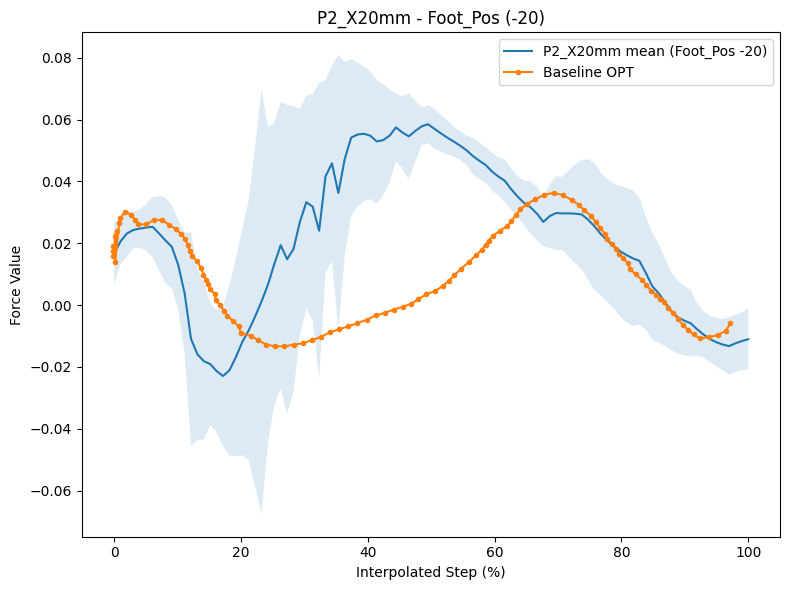

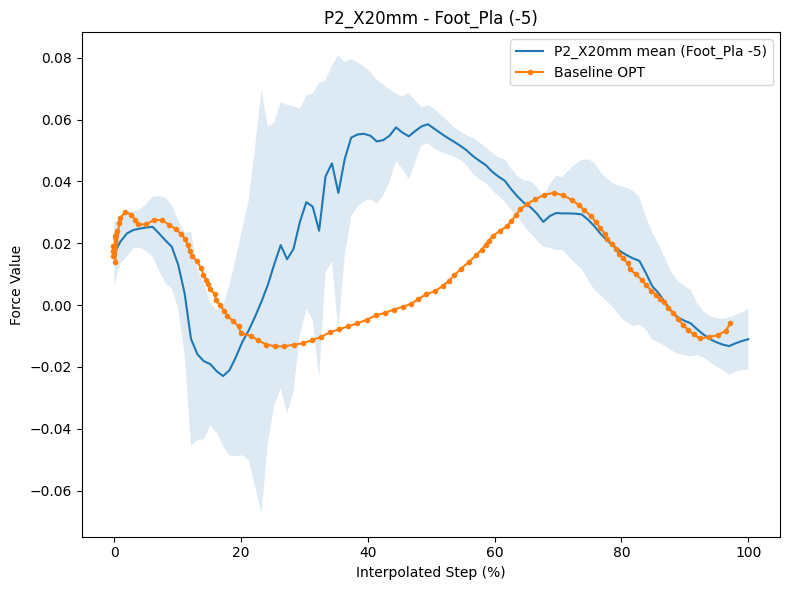

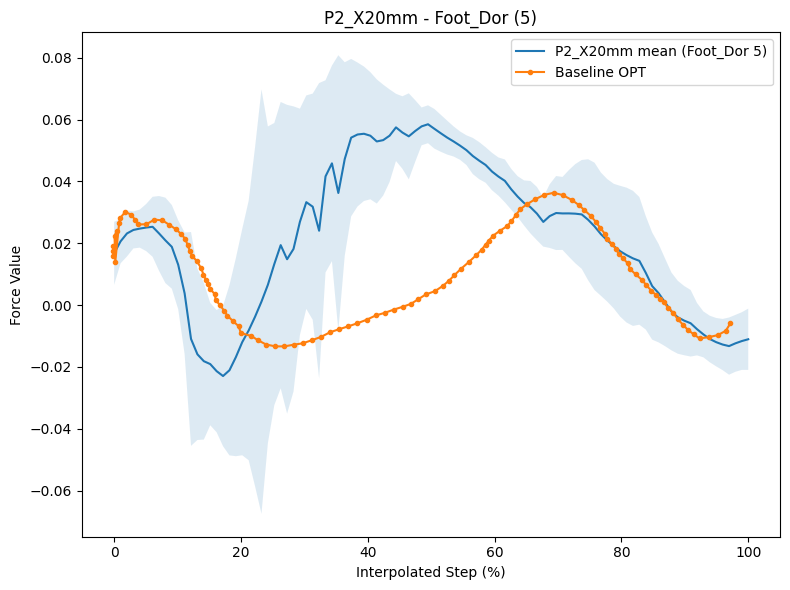

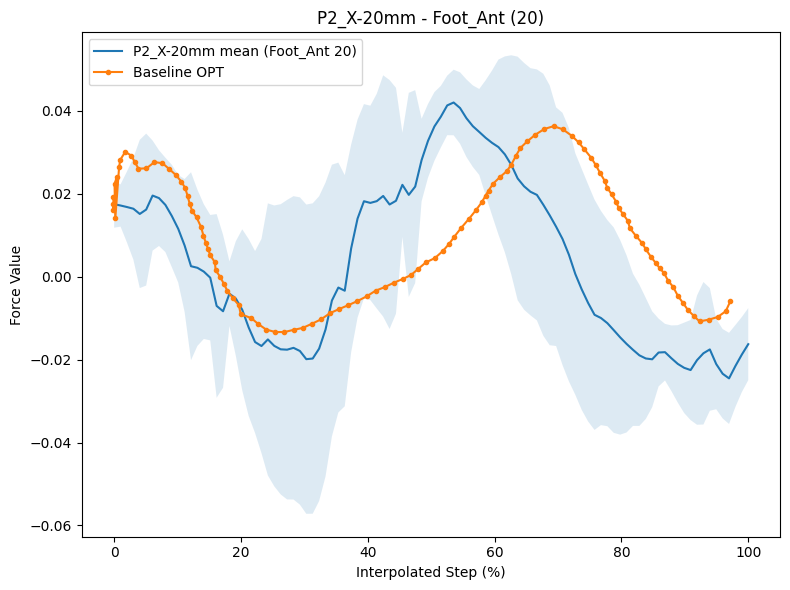

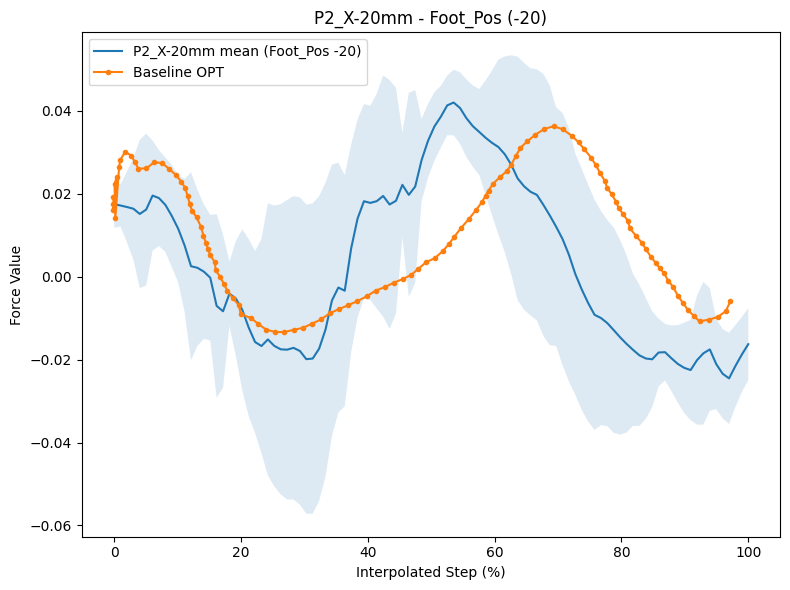

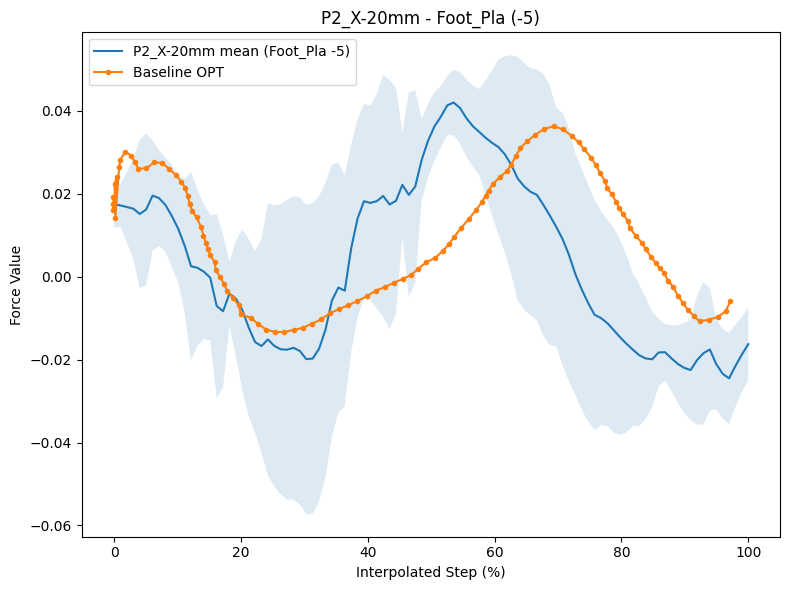

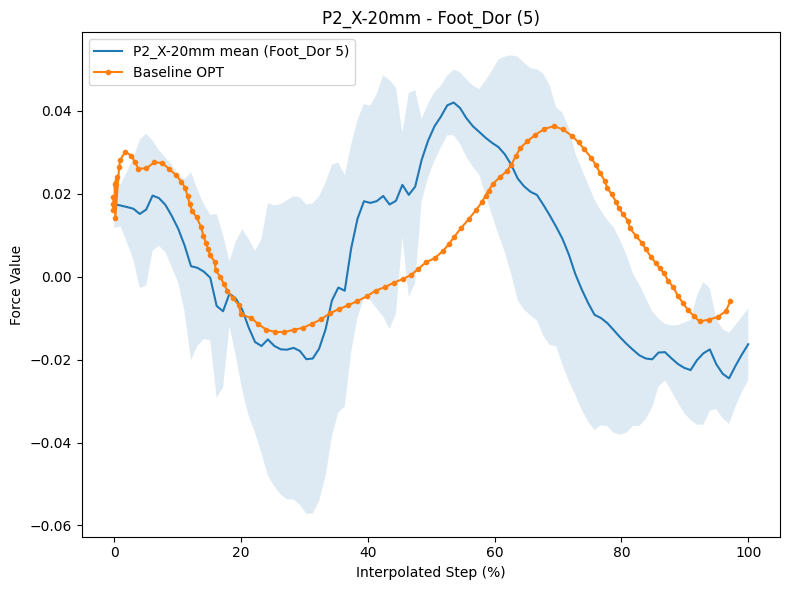

In [35]:
import re
# Plot Knee torque z with baseline data from Schmalz 

alignment_baseline_data = "/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Alignment_Data_Schmalz_2002.csv"


importlib.reload(eval_pros)
postprocess_handler = eval_pros.PostProcessMetricsHandler()
direction = "z"

postprocess_handler.plot_sensor_force_by_run_and_couple(
    all_loaded_data,
    run_step_data,
    direction,
    right_switches,
    left_switches,
    prosthesis_side='left',
    interp_len=100,
    body_weight_to_normalize=86.6*9.81,
    baseline_data=alignment_baseline_data
)

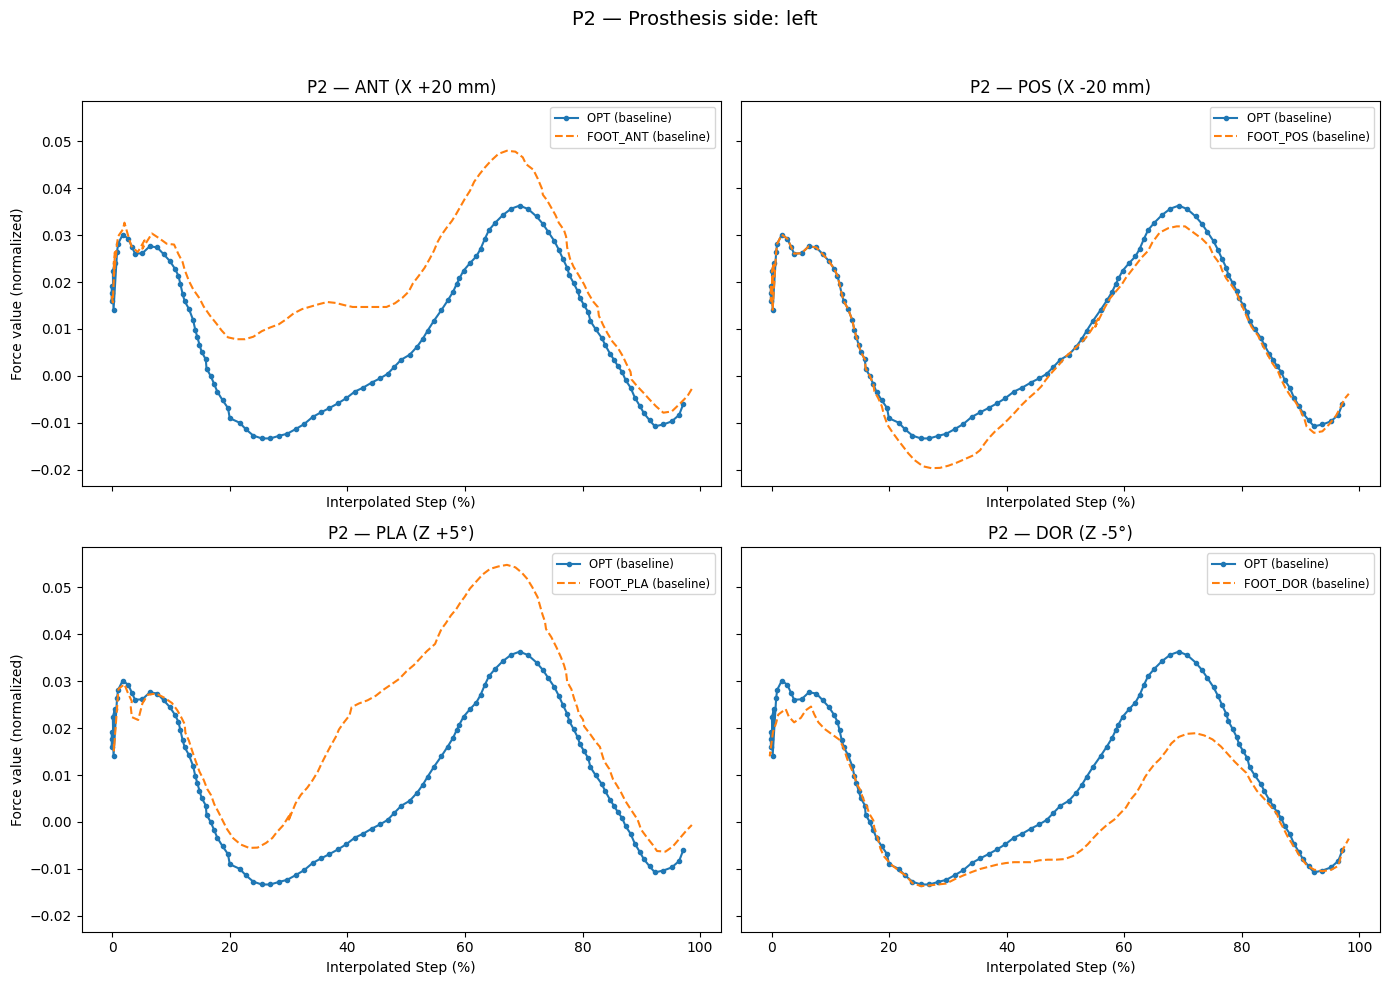

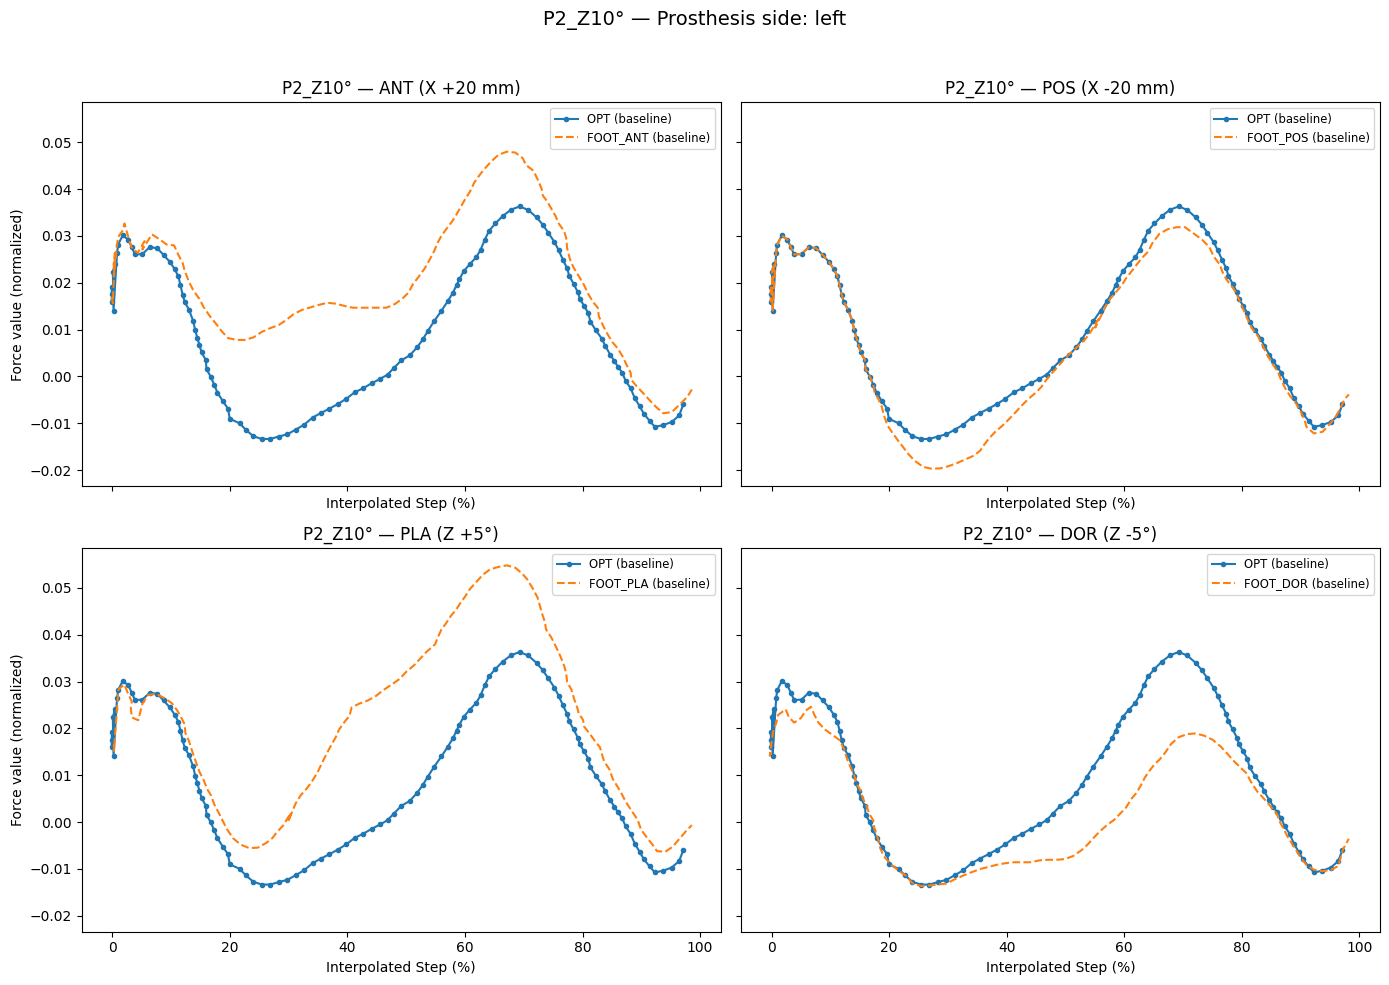

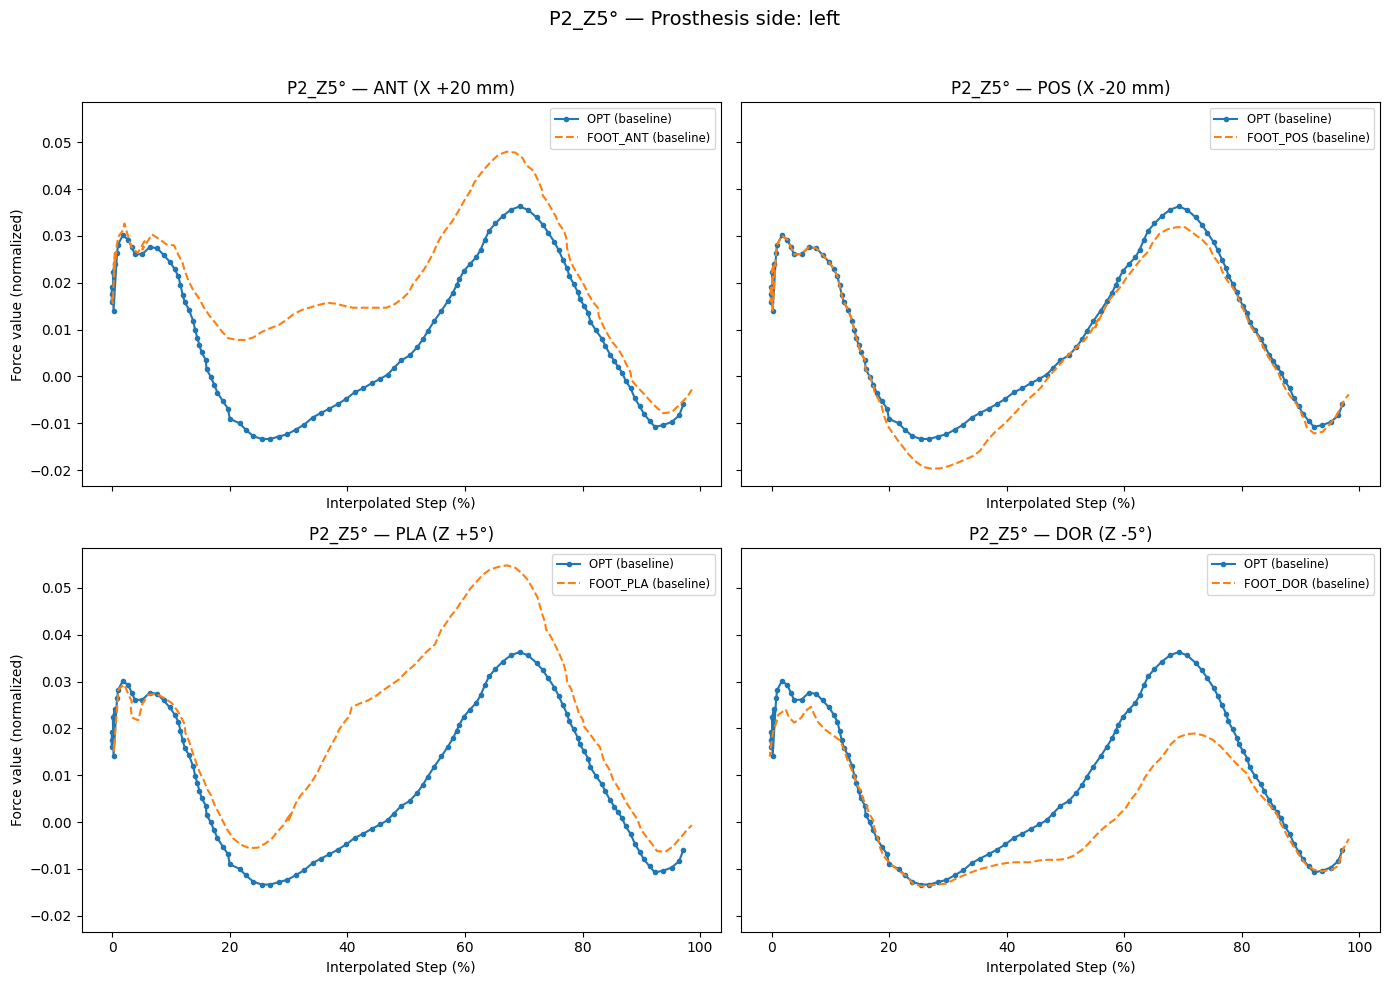

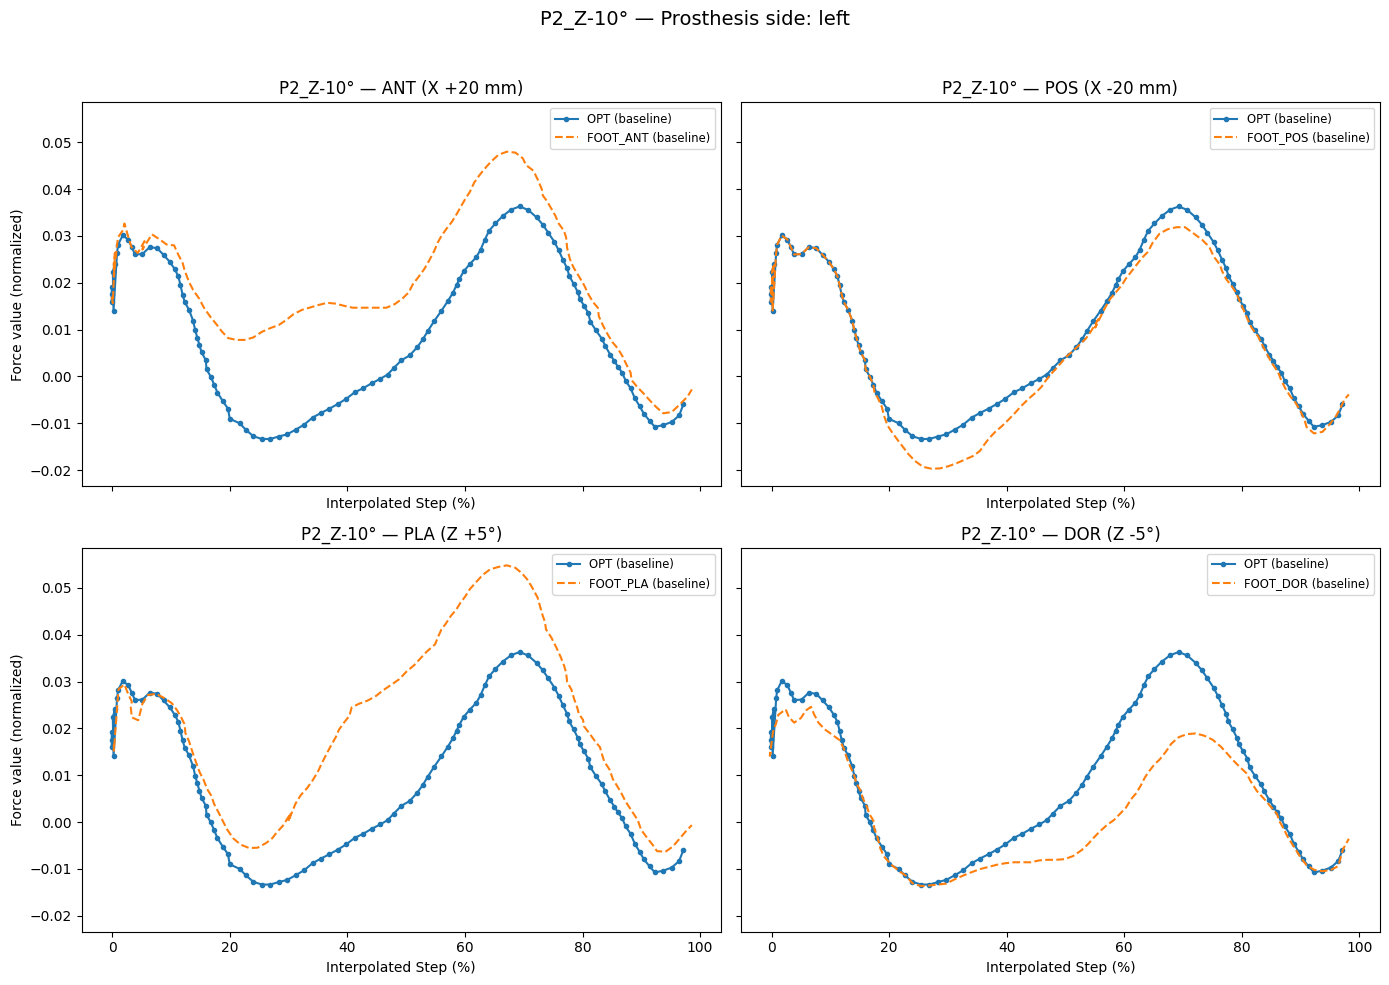

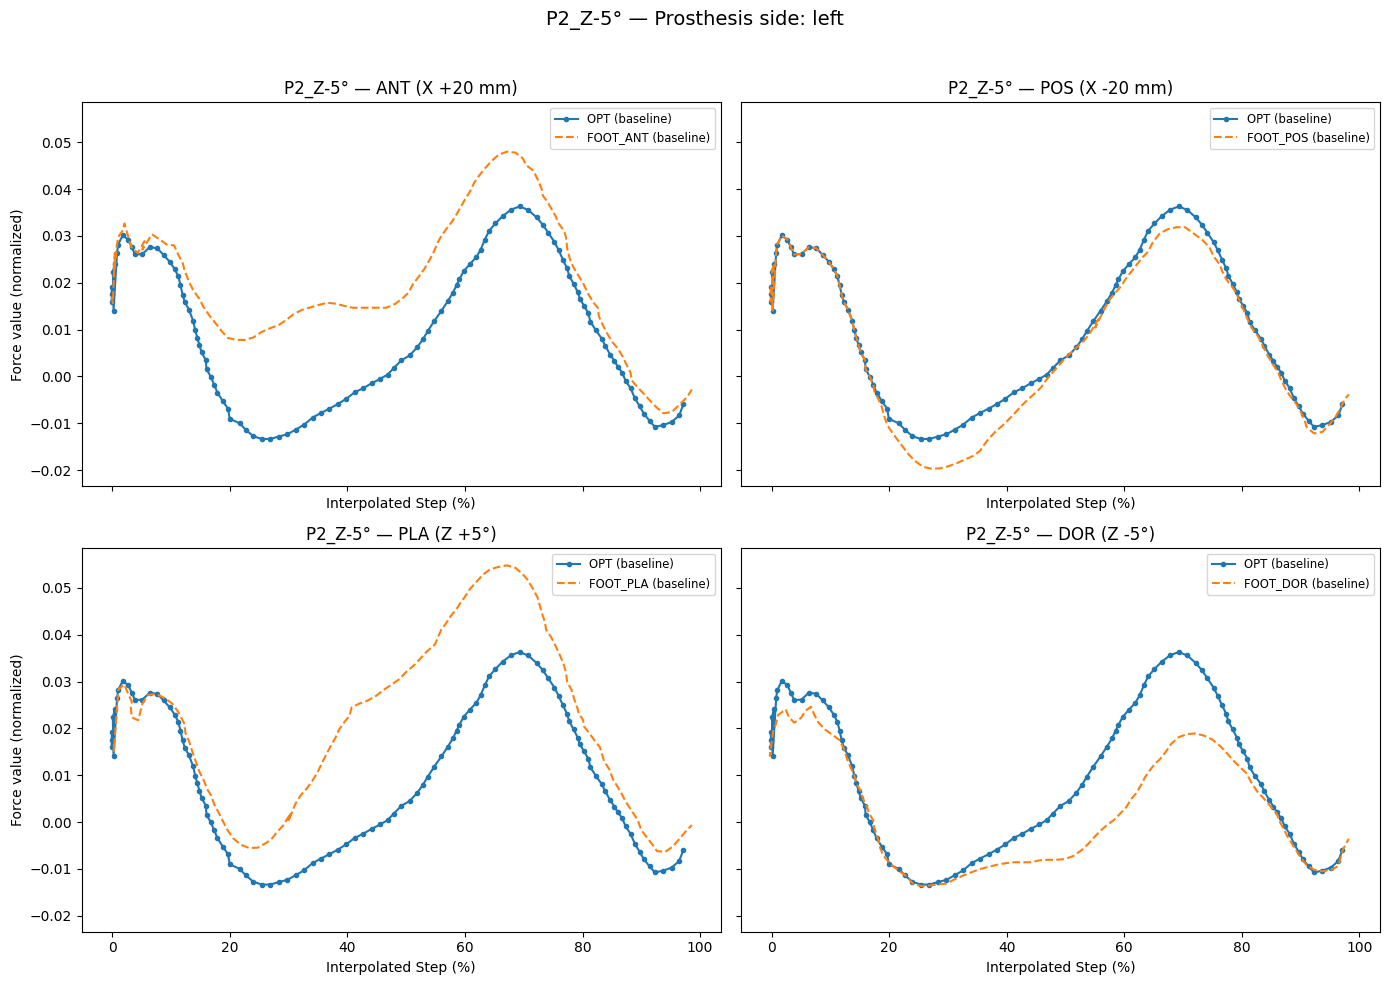

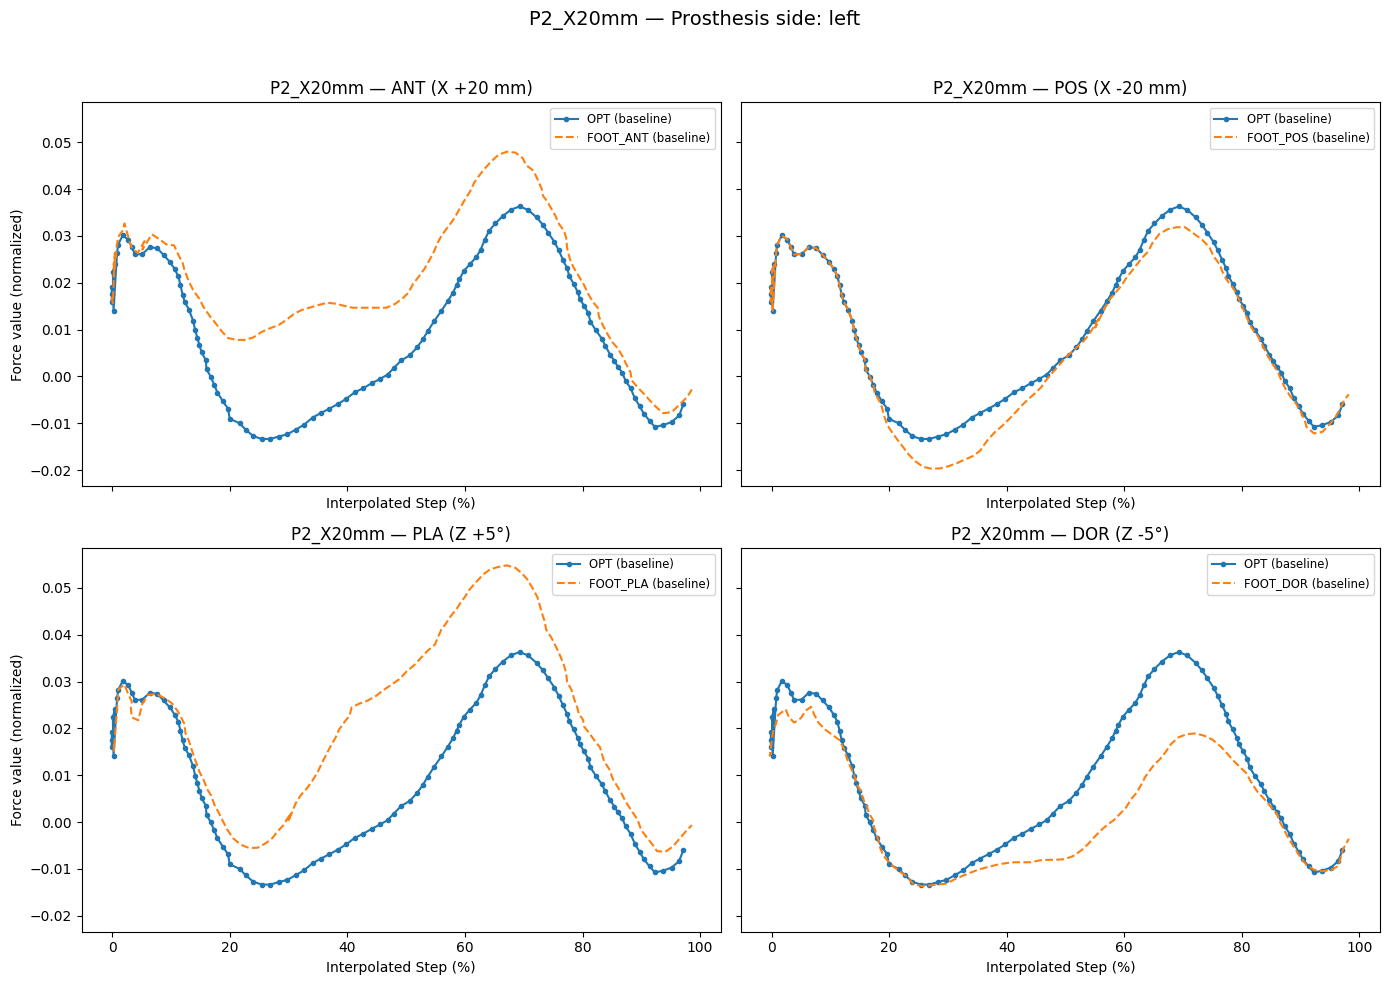

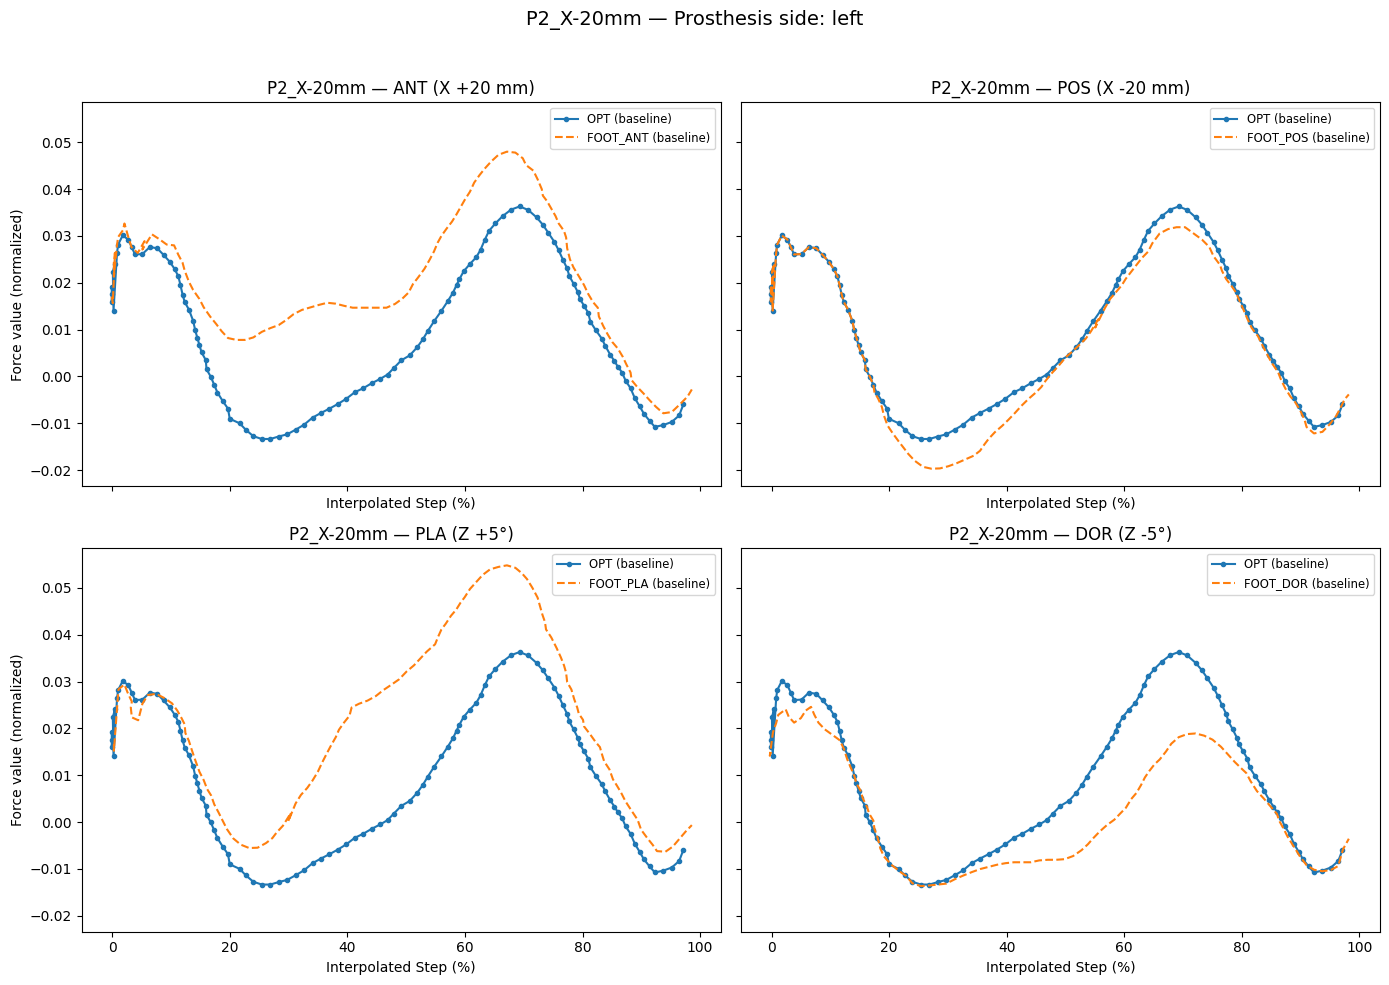

In [42]:
import re
# Plot Knee torque z with baseline data from Schmalz 

alignment_baseline_data = "/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Alignment_Data_Schmalz_2002.csv"


importlib.reload(eval_pros)
postprocess_handler = eval_pros.PostProcessMetricsHandler()
direction = "z"

postprocess_handler.plot_sensor_force_per_run_4subplots(
    all_loaded_data,
    run_step_data,
    direction,
    right_switches,
    left_switches,
    prosthesis_side='left',
    interp_len=100,
    body_weight_to_normalize=86.6*9.81,
    baseline_data=alignment_baseline_data
)

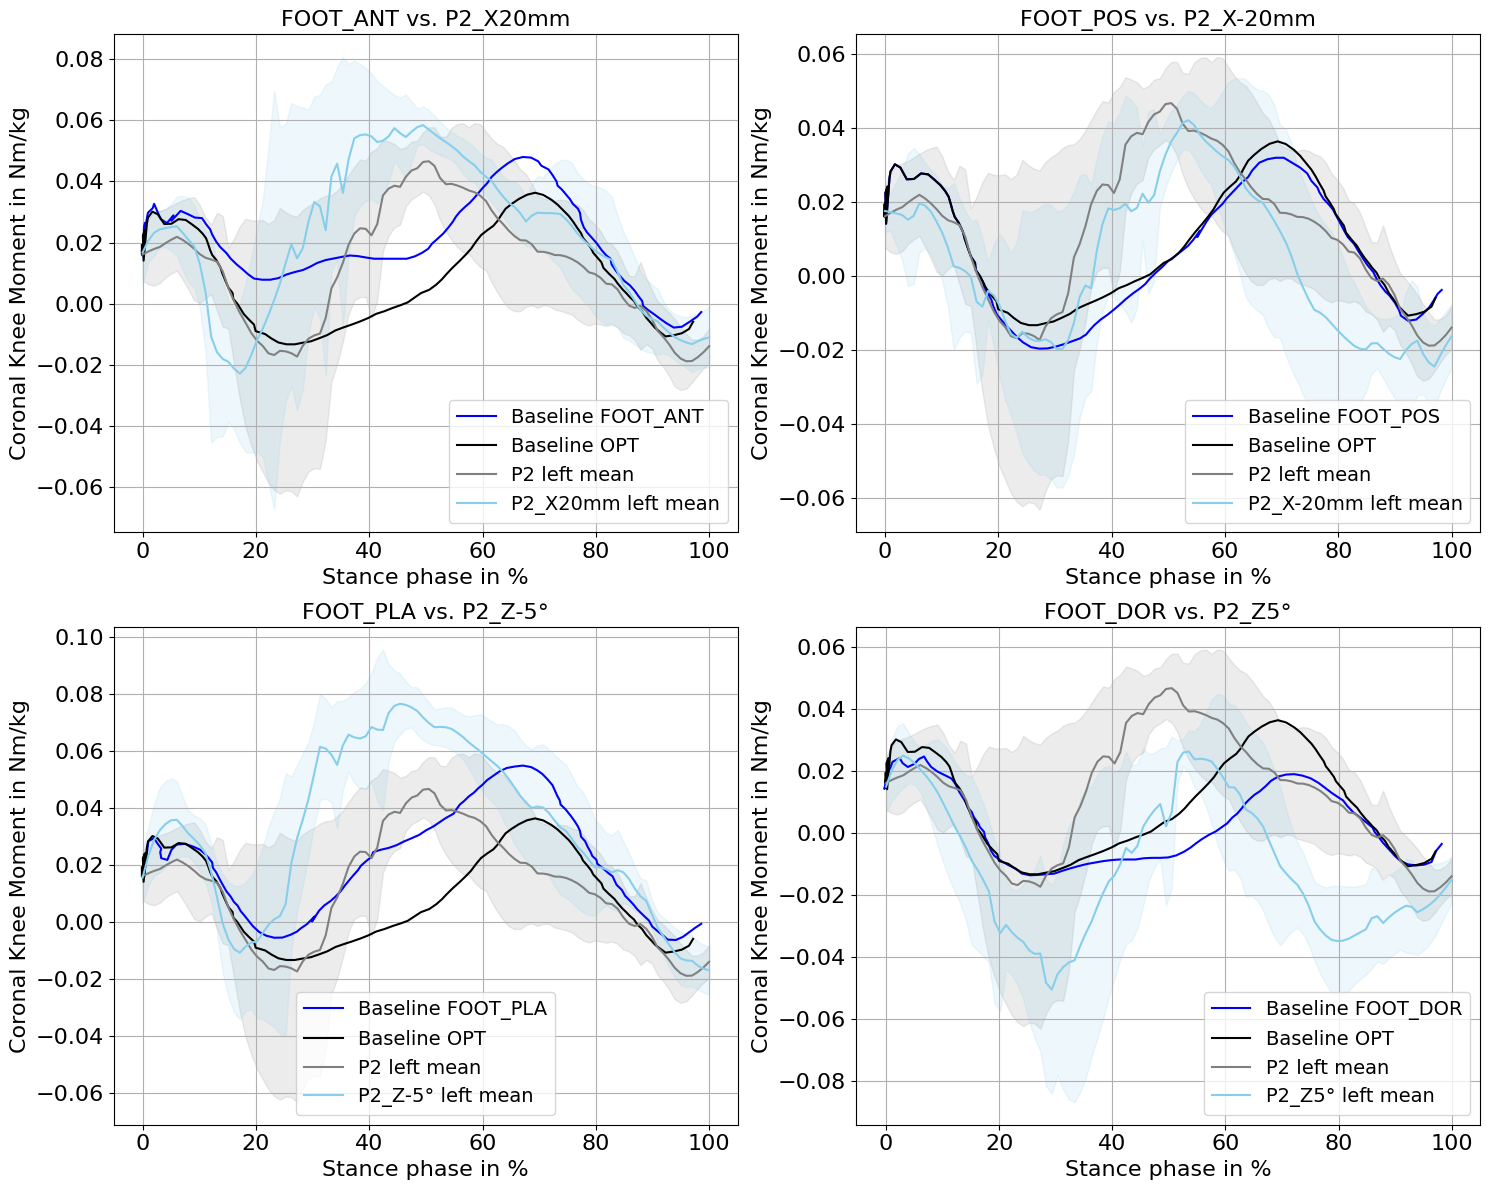

In [72]:
import re
# Plot Knee torque z with baseline data from Schmalz 

alignment_baseline_data = "/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Alignment_Data_Schmalz_2002.csv"


importlib.reload(eval_pros)
postprocess_handler = eval_pros.PostProcessMetricsHandler()
direction = "z"

postprocess_handler.plot_sensor_force_symmetry_four_panel_with_params(
    all_loaded_data,
    run_step_data,
    right_switches,
    left_switches,
    prosthesis_side='left',
    interp_len=100,
    body_weight_to_normalize=86.6*9.81,
    baseline_data_path=alignment_baseline_data
)



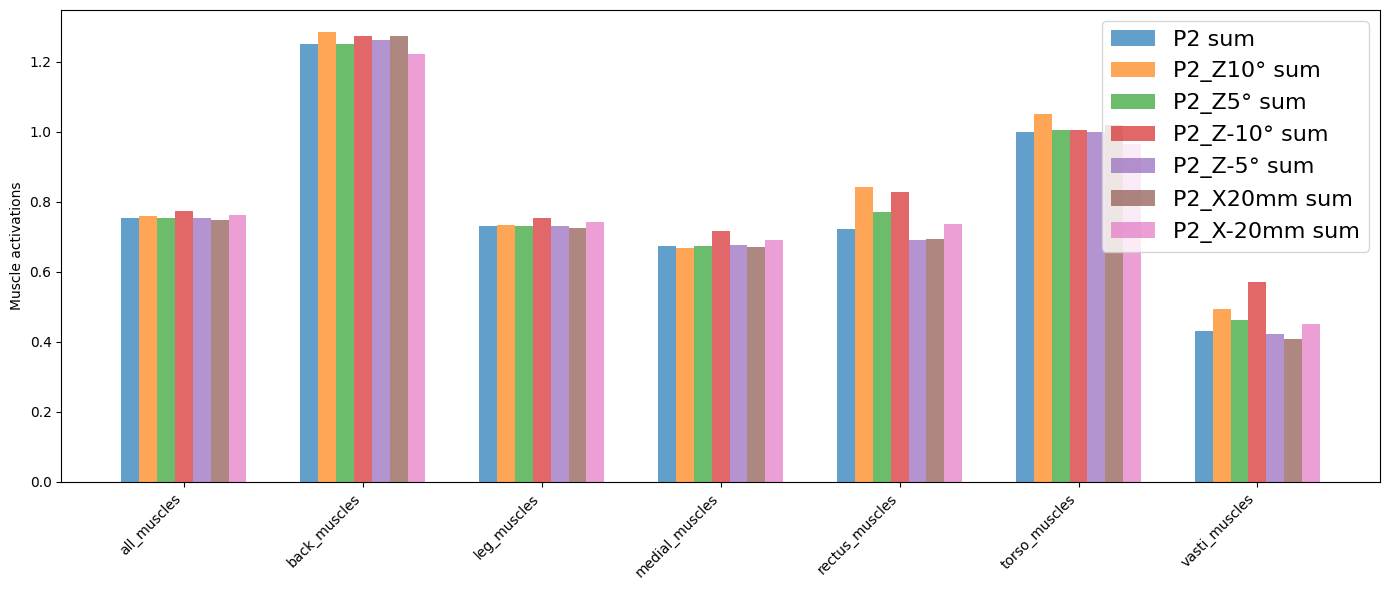

Number of muscles in each group: {'all_muscles': 46, 'back_muscles': 1, 'leg_muscles': 43, 'medial_muscles': 6, 'rectus_muscles': 1, 'torso_muscles': 2, 'vasti_muscles': 3}


In [6]:
# Calculate and plot the muscle activations for right and left summed up together
# Bar plot sum along all steps and muscles data for all muscles and all parameters (sum left+right for each muscle group)
n_steps = 1000

all_run_keys = list(all_loaded_data.keys())
# Get all muscle groups that appear as _left/_right in any run
all_muscle_groups = set()
for run_key in all_run_keys:
    run_dict = all_loaded_data[run_key]
    act = run_dict.get("sum_muscles_activations")
    if act is not None:
        mg = list(act.keys())
        all_muscle_groups.update([g.replace('_left', '') for g in mg if g.endswith('_left') and g.replace('_left', '_right') in mg])
all_muscle_groups = sorted(all_muscle_groups)

# Get number of muscles in each group from evaluation_muscle_names
n_musc = {}
if all_run_keys:
    # Use the first run to get evaluation_muscle_names
    run_dict = all_loaded_data[all_run_keys[0]]
    eval_muscle_names = run_dict.get("evaluation_muscle_names", {})
    for base in all_muscle_groups:
        n_musc[base] = len(eval_muscle_names.get(base, []))

# Bar plot for sum of left+right activations for all runs and all muscle groups
sum_matrix = []
std_matrix = []
for run_key in all_run_keys:
    run_dict = all_loaded_data[run_key]
    act = run_dict.get("sum_muscles_activations")
    vals = []
    stds = []
    for base in all_muscle_groups:
        left = act.get(f"{base}_left") if act else None
        right = act.get(f"{base}_right") if act else None
        left_std = act.get(f"{base}_left_std") if act else None
        right_std = act.get(f"{base}_right_std") if act else None
        # Convert to scalar
        if isinstance(left, tuple):
            left = left[0]
        if hasattr(left, "item"):
            left = left.item()
        if isinstance(right, tuple):
            right = right[0]
        if hasattr(right, "item"):
            right = right.item()
        # Sum left and right
        total = (left if left is not None else 0) + (right if right is not None else 0)
        vals.append(total if (left is not None or right is not None) else np.nan)
        # Compute std (sqrt of sum of variances, assuming independence)
        if left_std is not None and right_std is not None:
            std = np.sqrt(left_std**2 + right_std**2)
        elif left_std is not None:
            std = left_std
        elif right_std is not None:
            std = right_std
        else:
            std = np.nan
        stds.append(std)
    sum_matrix.append(vals)
    std_matrix.append(stds)

# Divide each group's summed activation and std by the number of muscles in that group and n_steps
sum_matrix = np.array(sum_matrix)
std_matrix = np.array(std_matrix)
for i, base in enumerate(all_muscle_groups):
    if n_musc.get(base, 1) > 0:
        sum_matrix[:, i] = sum_matrix[:, i] / (n_musc[base] * n_steps)
        std_matrix[:, i] = std_matrix[:, i] / (n_musc[base] * n_steps)

bar_width = 0.1
x = np.arange(len(all_muscle_groups))
plt.figure(figsize=(14, 6))
for i, run_key in enumerate(all_run_keys):
    bars = plt.bar(x + i * bar_width, sum_matrix[i], width=bar_width, label=f"{run_key} sum", alpha=0.7)
    # Add vertical lines for std
    for j in range(len(all_muscle_groups)):
        bar_center = x[j] + i * bar_width
        mean = sum_matrix[i, j]
        std = std_matrix[i, j]
        if not np.isnan(mean) and not np.isnan(std):
            plt.plot([bar_center, bar_center], [mean - std, mean + std], color='black', linewidth=2)
plt.xticks(x + bar_width * (len(all_run_keys)-1)/2, all_muscle_groups, rotation=45, ha='right')
plt.ylabel("Muscle activations")
# plt.title("Step- and Muscle-Normalized Activations (Left+Right summed, mean ± std) for All Runs")
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()
plt.close()

# n_musc now contains the number of muscles in each group
print("Number of muscles in each group:", n_musc)

left_std None
right_std None
left_std None
right_std None
left_std None
right_std None
left_std None
right_std None
left_std None
right_std None
left_std None
right_std None
left_std None
right_std None


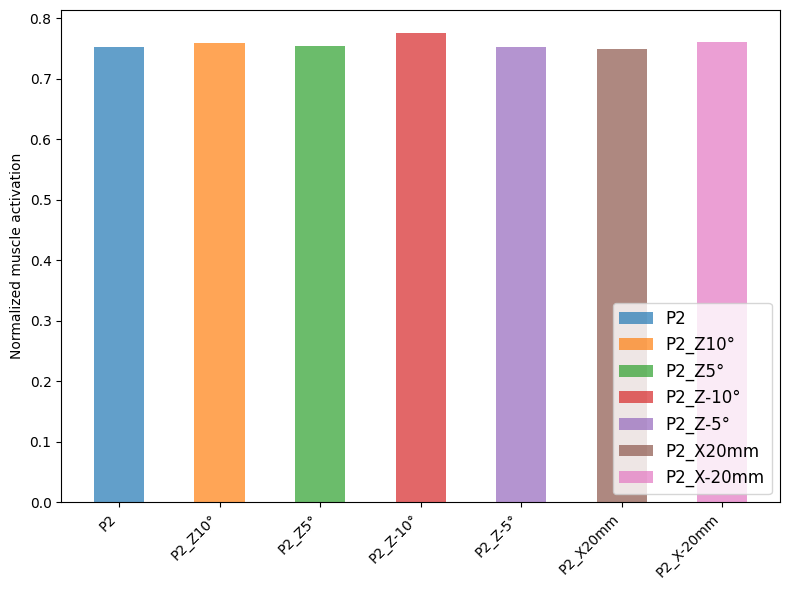

Number of muscles in 'all_muscles': 46
std_matrix [nan nan nan nan nan nan nan]


In [23]:
# Calculate and plot the muscle activations for right and left summed up together
# Bar plot sum along all steps and muscles data for all muscles and all parameters (sum left+right for each muscle group)
# The user's code starts here, with necessary adjustments.
n_steps = 1000

all_run_keys = list(all_loaded_data.keys())

# Get only the 'all_muscles' group
all_muscle_groups = ['all_muscles']

# Get number of muscles for the 'all_muscles' group
n_musc = {}
if all_run_keys:
    run_dict = all_loaded_data[all_run_keys[0]]
    eval_muscle_names = run_dict.get("evaluation_muscle_names", {})
    # This assumes 'all_muscles' is a key in evaluation_muscle_names
    n_musc['all_muscles'] = len(eval_muscle_names.get('all_muscles', []))

# Bar plot for 'all_muscles' activation
sum_matrix = []
std_matrix = []
for run_key in all_run_keys:
    run_dict = all_loaded_data[run_key]
    act = run_dict.get("sum_muscles_activations")
    
    # Process 'all_muscles' data
    left = act.get("all_muscles_left") if act else None
    right = act.get("all_muscles_right") if act else None
    left_std = act.get("all_muscles_left_std") if act else None
    right_std = act.get("all_muscles_right_std") if act else None
    
    # Convert to scalar, if necessary
    if isinstance(left, tuple): left = left[0]
    if hasattr(left, "item"): left = left.item()
    if isinstance(right, tuple): right = right[0]
    if hasattr(right, "item"): right = right.item()

    # Sum left and right activations
    total_sum = (left if left is not None else 0) + (right if right is not None else 0)
    print('left_std', left_std)
    print('right_std', right_std)
    # Compute std (sqrt of sum of variances)
    if left_std is not None and right_std is not None:
        # print('left_std', left_std)
        # print('right_std', right_std)
        total_std = np.sqrt(left_std**2 + right_std**2)
    elif left_std is not None:
        total_std = left_std
    elif right_std is not None:
        total_std = right_std
    else:
        total_std = np.nan
        
    sum_matrix.append(total_sum if (left is not None or right is not None) else np.nan)
    std_matrix.append(total_std)

# Normalize by the number of muscles and n_steps
num_muscles = n_musc.get('all_muscles', 1)
sum_matrix = np.array(sum_matrix) / (num_muscles * n_steps)
std_matrix = np.array(std_matrix) #/ (num_muscles * n_steps)

# Plotting
bar_width = 0.5
x = np.arange(len(all_run_keys))
plt.figure(figsize=(8, 6))

for i, run_key in enumerate(all_run_keys):

    bar = plt.bar(x[i], sum_matrix[i], width=bar_width, label=run_key, alpha=0.7)
    
    # Add error bar for std
    mean = sum_matrix[i]
    std = std_matrix[i]
    if not np.isnan(mean) and not np.isnan(std):
        plt.errorbar(x[i], mean, yerr=std, color='black', capsize=5, fmt='none', ecolor='black')

plt.xticks(x, all_run_keys, rotation=45, ha='right')
plt.ylabel("Normalized muscle activation")
# plt.title("Normalized Activations for 'all_muscles' (Mean ± Std)")
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()

# Print the number of muscles in 'all_muscles' group
print("Number of muscles in 'all_muscles':", n_musc.get('all_muscles'))
print('std_matrix', std_matrix)